# Data coverage & quality inspection

Quick health check of the curated Massive store: what is there, gaps versus the NYSE calendar, and sanity checks on bars.

In [1]:
import datetime as dt
import polars as pl
import matplotlib.pyplot as plt

from collective_alpha.storage.catalog import Catalog
from collective_alpha.calendar import trading_days

cat = Catalog()
cat.tables()

['conditions',
 'conditions_history',
 'day_aggs',
 'dividends',
 'dividends_history',
 'exchanges',
 'exchanges_history',
 'float',
 'float_history',
 'ipos',
 'ipos_history',
 'market_holidays',
 'market_holidays_history',
 'minute_aggs',
 'news',
 'short_interest',
 'short_volume',
 'splits',
 'splits_history',
 'tickers',
 'tickers_history',
 'ticker_details',
 'ticker_details_history',
 'ticker_events',
 'ticker_events_history',
 'ticker_types',
 'ticker_types_history']

## Daily bars: rows and tickers per day

In [2]:
daily = cat.sql('''
    select date, count(*) as rows, count(distinct ticker) as tickers,
           sum(volume) as volume
    from day_aggs group by date order by date
''').pl()
daily.tail()

date,rows,tickers,volume
date,i64,i64,f64
2026-09-04,12485,12485,1.3533e10
2026-09-08,12507,12507,1.6249e10
2026-09-09,12495,12495,1.5333e10
2026-09-10,12559,12559,1.5833e10
2026-09-11,12455,12455,1.4453e10


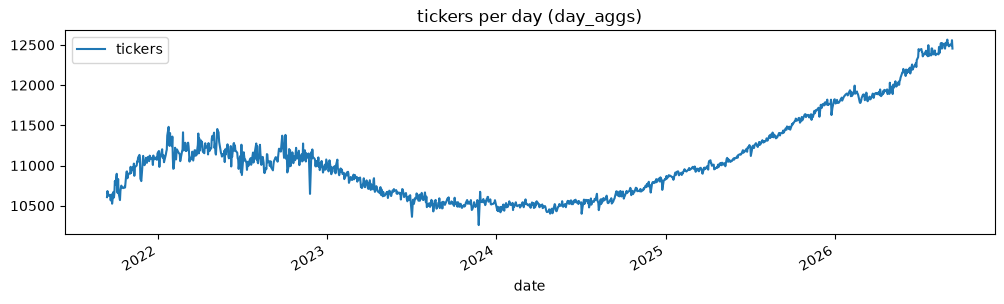

In [3]:
ax = daily.to_pandas().set_index('date')[['tickers']].plot(figsize=(12, 3), title='tickers per day (day_aggs)')

## Missing trading days

In [4]:
have = set(daily['date'].to_list())
expected = trading_days(daily['date'].min(), daily['date'].max())
missing = [d for d in expected if d not in have]
print(len(missing), 'missing days'); missing[:20]

0 missing days


[]

## Minute bars: bars per day and session boundaries

In [5]:
minute = cat.sql('''
    select date, count(*) as rows, count(distinct ticker) as tickers,
           min(ts_ny) as first_bar, max(ts_ny) as last_bar
    from minute_aggs group by date order by date
''').pl()
minute.tail()

date,rows,tickers,first_bar,last_bar
date,i64,i64,datetime[ns],datetime[ns]
2026-09-04,1752279,11816,2026-09-04 04:00:00,2026-09-04 20:00:00
2026-09-08,1845118,11900,2026-09-08 04:00:00,2026-09-08 20:00:00
2026-09-09,1822074,11869,2026-09-09 04:00:00,2026-09-09 19:59:00
2026-09-10,1833699,11956,2026-09-10 04:00:00,2026-09-10 19:59:00
2026-09-11,1776289,11771,2026-09-11 04:00:00,2026-09-11 19:59:00


## Sanity checks on OHLC

In [6]:
cat.sql('''
    select count(*) filter (where high < low) as high_lt_low,
           count(*) filter (where open > high or open < low) as open_outside,
           count(*) filter (where close > high or close < low) as close_outside,
           count(*) filter (where volume <= 0) as nonpositive_volume,
           count(*) as total
    from day_aggs
''').pl()

high_lt_low,open_outside,close_outside,nonpositive_volume,total
i64,i64,i64,i64,i64
0,0,0,99997,13892534


## Reference tables

In [7]:
cat.sql('select active, count(*) as n from tickers group by active').pl()

active,n
bool,i64
false,23407
true,13181


In [8]:
cat.sql('select type, count(*) as n from tickers where active group by type order by n desc limit 15').pl()

type,n
str,i64
"""ETF""",5449
"""CS""",5320
"""WARRANT""",440
"""PFD""",429
"""ADRC""",376
…,…
"""SP""",160
"""RIGHT""",125
"""ETS""",107


In [9]:
cat.sql('select * from splits order by execution_date desc limit 10').pl()

execution_date,id,split_from,split_to,ticker,asof
str,str,f64,f64,str,date
"""2026-12-17""","""Ee311332e3f60ade13ccbf987b2d89…",50.0,1.0,"""DPU""",2026-09-13
"""2026-11-05""","""E75e42c53b07756b6ddede7c472e7a…",1.0,3.0,"""SOXX""",2026-09-13
"""2026-10-12""","""Ea8cf9271ba4dc2116d5d1c5393b42…",100.0,192.0,"""IDTID""",2026-09-13
"""2026-10-09""","""E0faa7d94e6d489275a0263279117a…",1.0,3.0,"""KXIAY""",2026-09-13
"""2026-10-09""","""Ecf2263d038794d0f275e4ec92f121…",1.0,2.0,"""IMHDY""",2026-09-13
"""2026-10-09""","""Ea4cd88be2183271fffbe5a7fd4c6f…",1.0,2.0,"""DWAHY""",2026-09-13
"""2026-10-07""","""E45fa8c1e8f11792ed413918a83eae…",1.0,2.0,"""TOPPY""",2026-09-13
"""2026-10-06""","""E70c2eb452e21e8b91d42508f98216…",3.0,1.0,"""ETHA""",2026-09-13
"""2026-10-05""","""E94301acb8c6cb84ca3079b5bef659…",1.0,5.0,"""TGOSY""",2026-09-13
